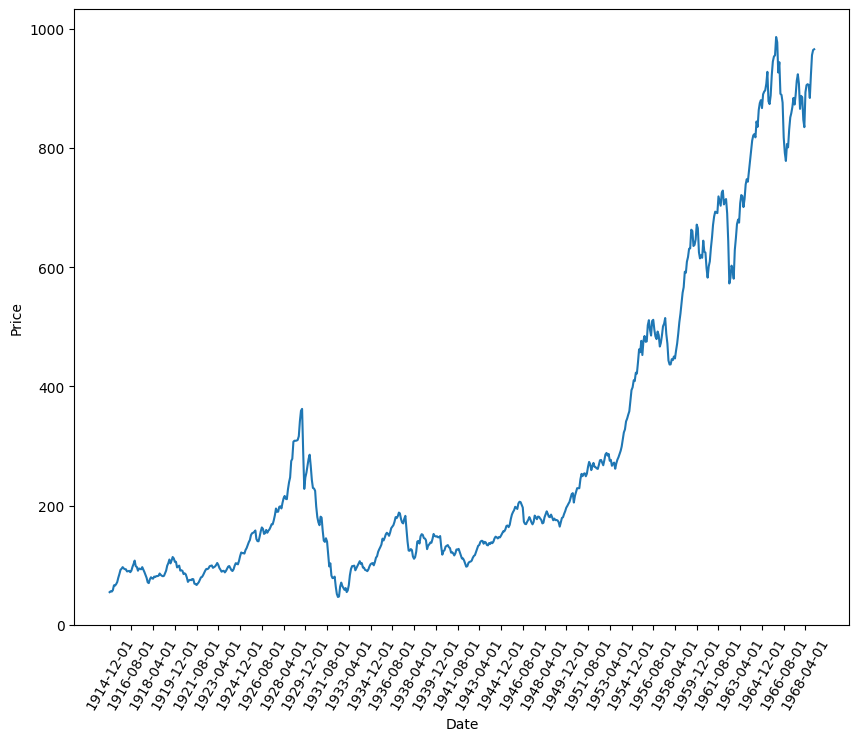

In [9]:

#===========================================================================
#LINE PLOT
#============================================================================ 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_stocks = sns.load_dataset("dowjones")
# print(df_stocks)


plt.figure(figsize=(10,8))
sns.lineplot(df_stocks,x='Date',y='Price')
_=plt.xticks(df_stocks['Date'][::20],rotation = 60)

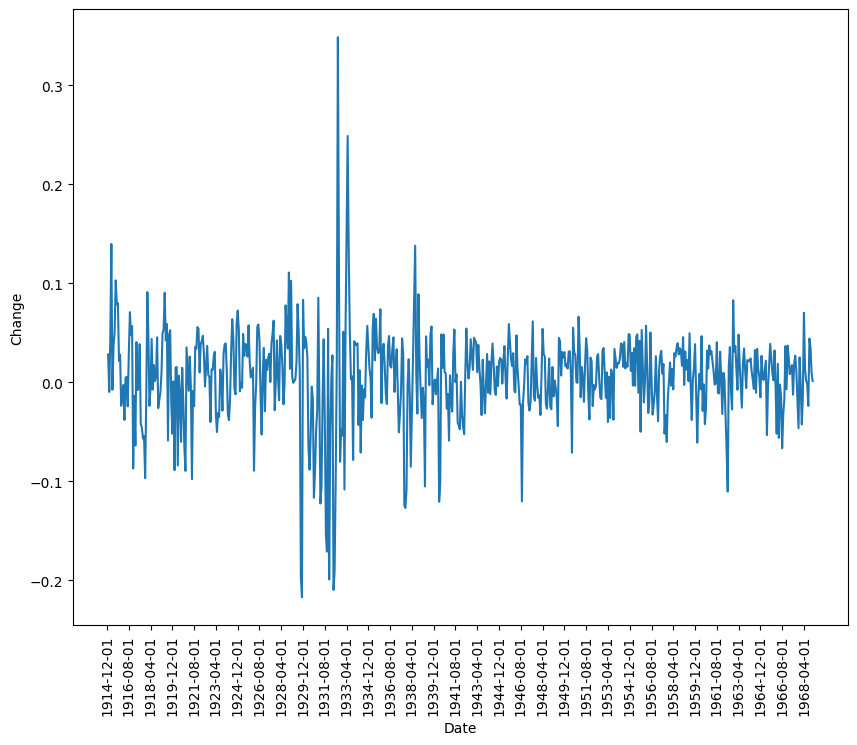

In [11]:
#A new function showing the percent change from adjacent values:
df_stocks["Change"] = df_stocks["Price"].pct_change()

plt.figure(figsize=(10,8))
sns.lineplot(df_stocks, x="Date", y="Change")
_=plt.xticks(df_stocks["Date"][::20], rotation=90)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

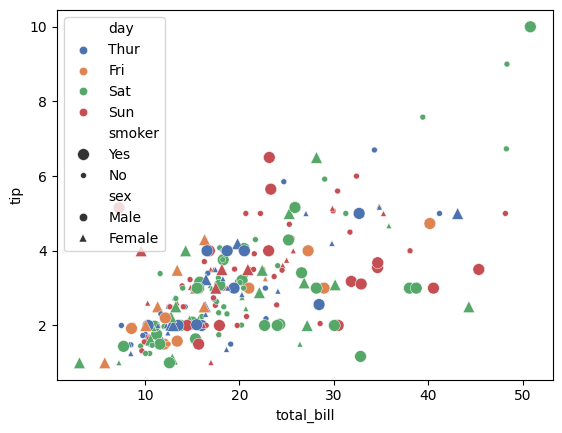

In [15]:

#===========================================================================
#SCATTER PLOT
#============================================================================ 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_tips = sns.load_dataset("tips")
print(df_tips)

sns.scatterplot(df_tips, x ='total_bill', y = 'tip',hue= 'day',size = 'smoker',style = 'sex', markers = ['o','^'], palette = 'deep')

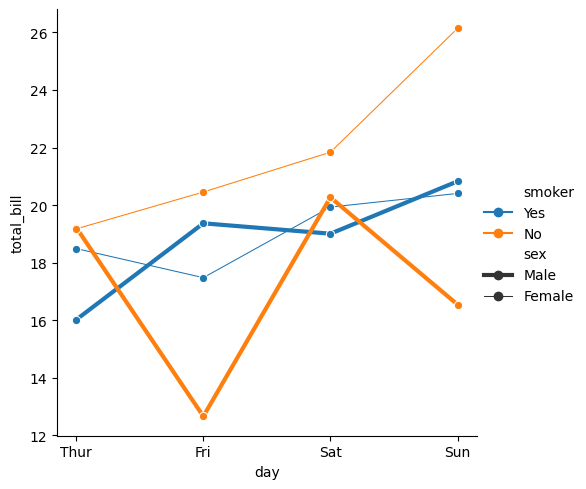

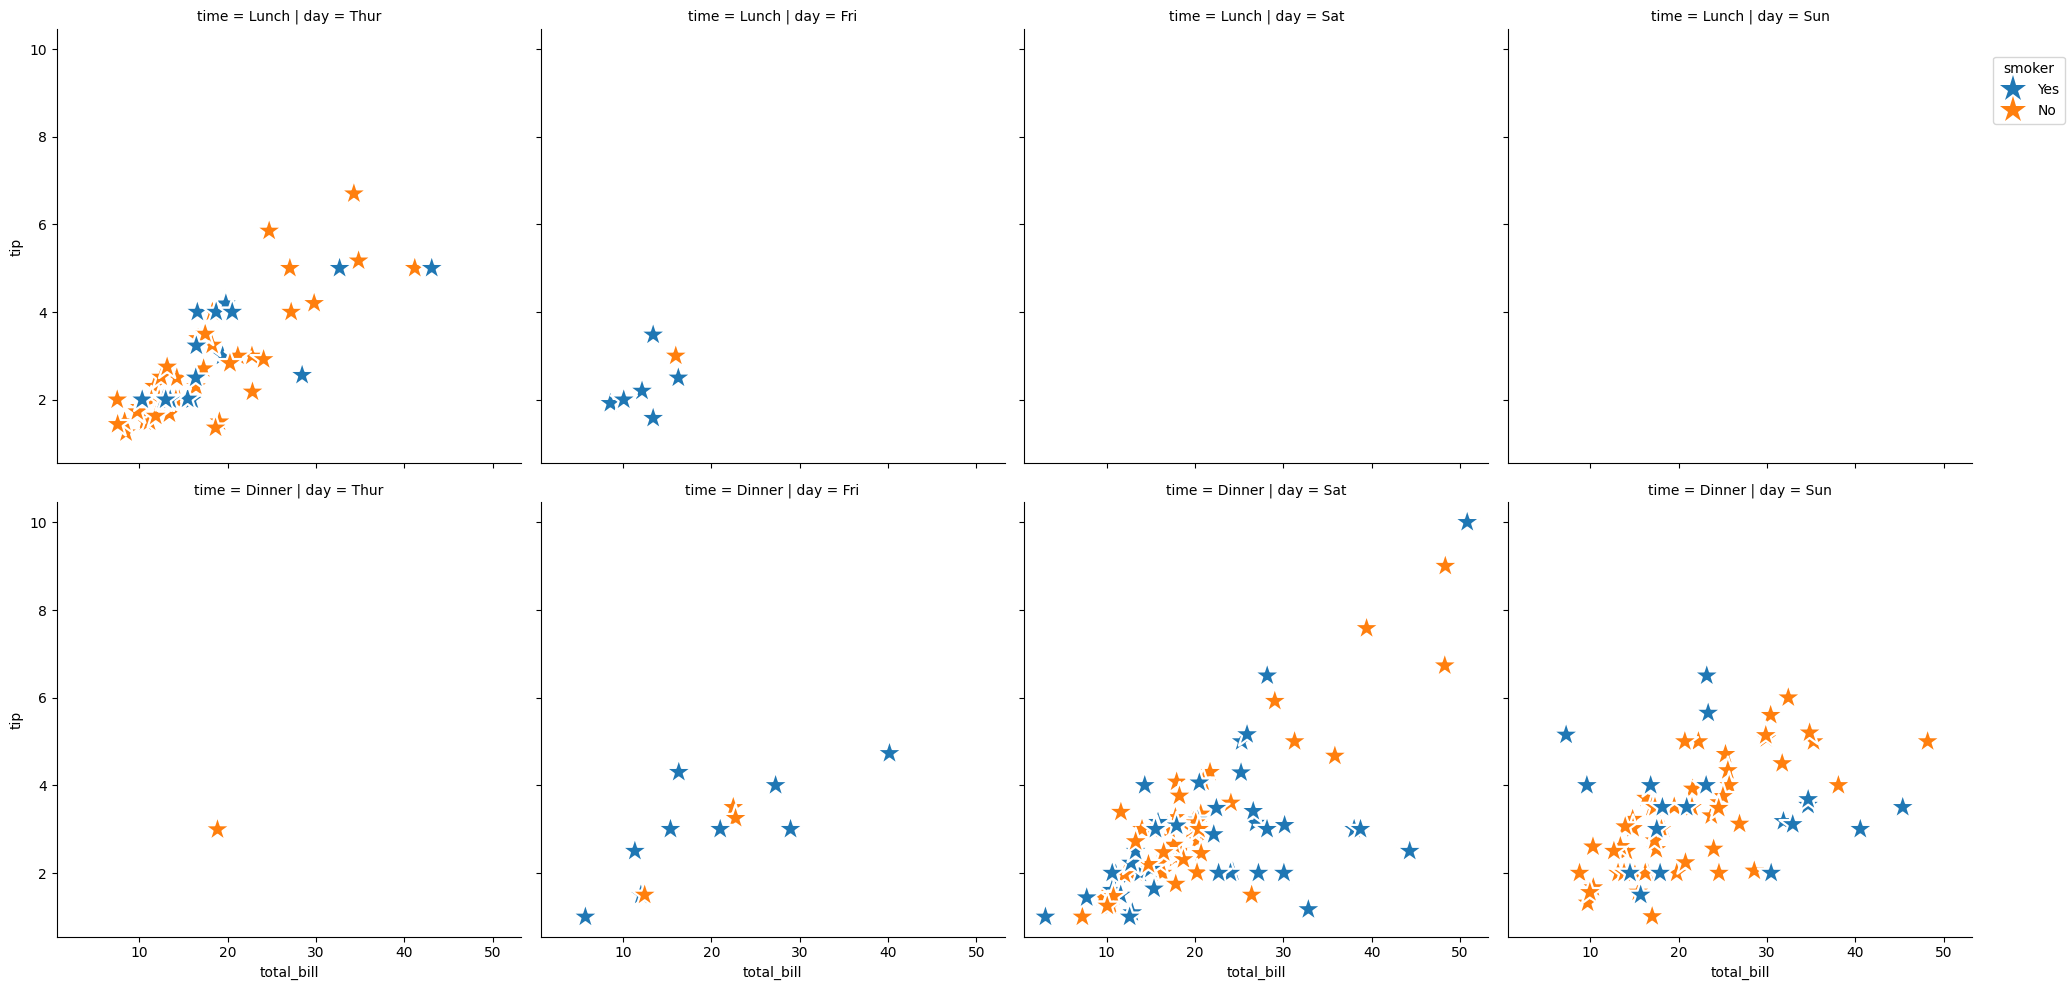

In [16]:


#===========================================================================
#RELATIONAL PLOT

#============================================================================ 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_tips = sns.load_dataset("tips")


sns.relplot(df_tips,x="day", y="total_bill", hue="smoker", size="sex" ,
            marker="o", kind="line", errorbar=None)
plt.show()

g = sns.relplot(df_tips,x="total_bill", y="tip", col="day", row="time", 
            hue="smoker",  marker="*", kind="scatter", s=400)
            
#Fine tune the legend manually.
leg = g._legend
leg.set_bbox_to_anchor([1.0, 0.9])            
leg.set_frame_on(True)
plt.show()

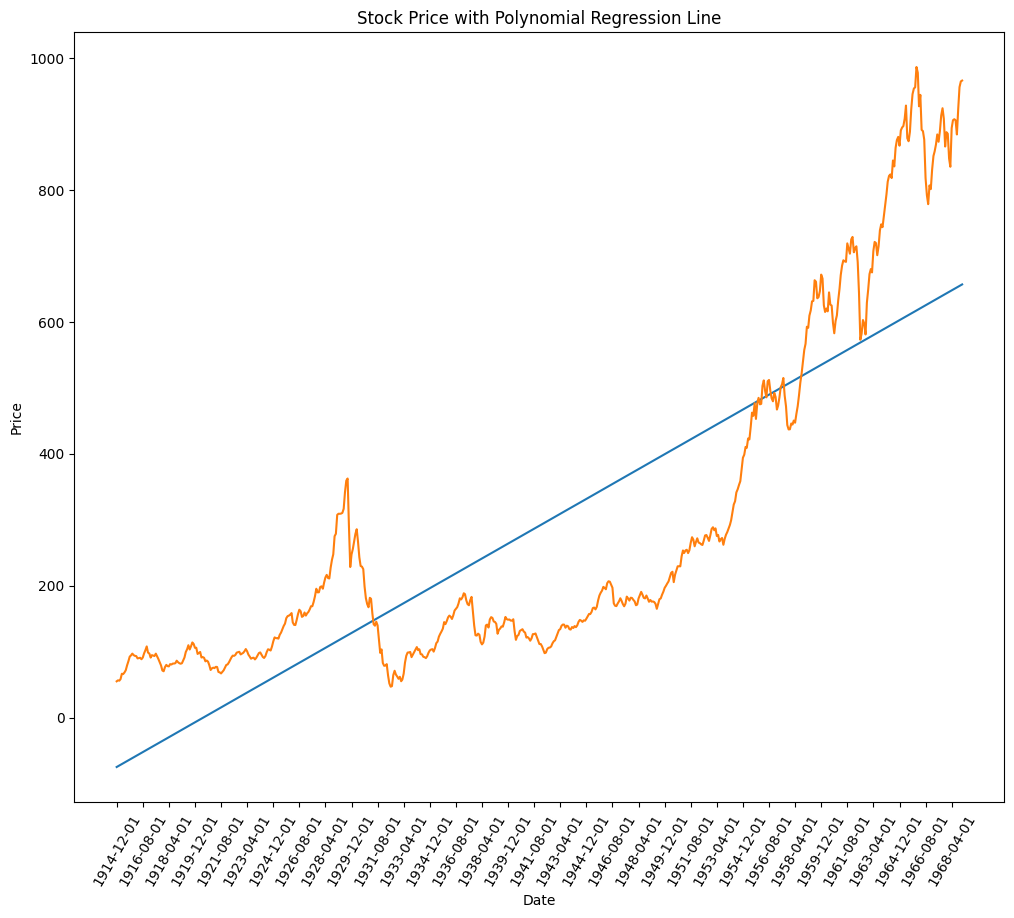

In [17]:


#===========================================================================
#Regression Line

#============================================================================ 

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_stocks = sns.load_dataset("dowjones")
x = (df_stocks.index+11)/12+1914
lin_reg = np.polynomial.Polynomial.fit(x,df_stocks["Price"], 1)
plt.figure(figsize=(12,10))
plt.plot(df_stocks["Date"], lin_reg(x))
sns.lineplot(df_stocks, x="Date", y="Price")
plt.title("Stock Price with Polynomial Regression Line")
plt.xticks(df_stocks["Date"][::20], rotation=60)
plt.show()


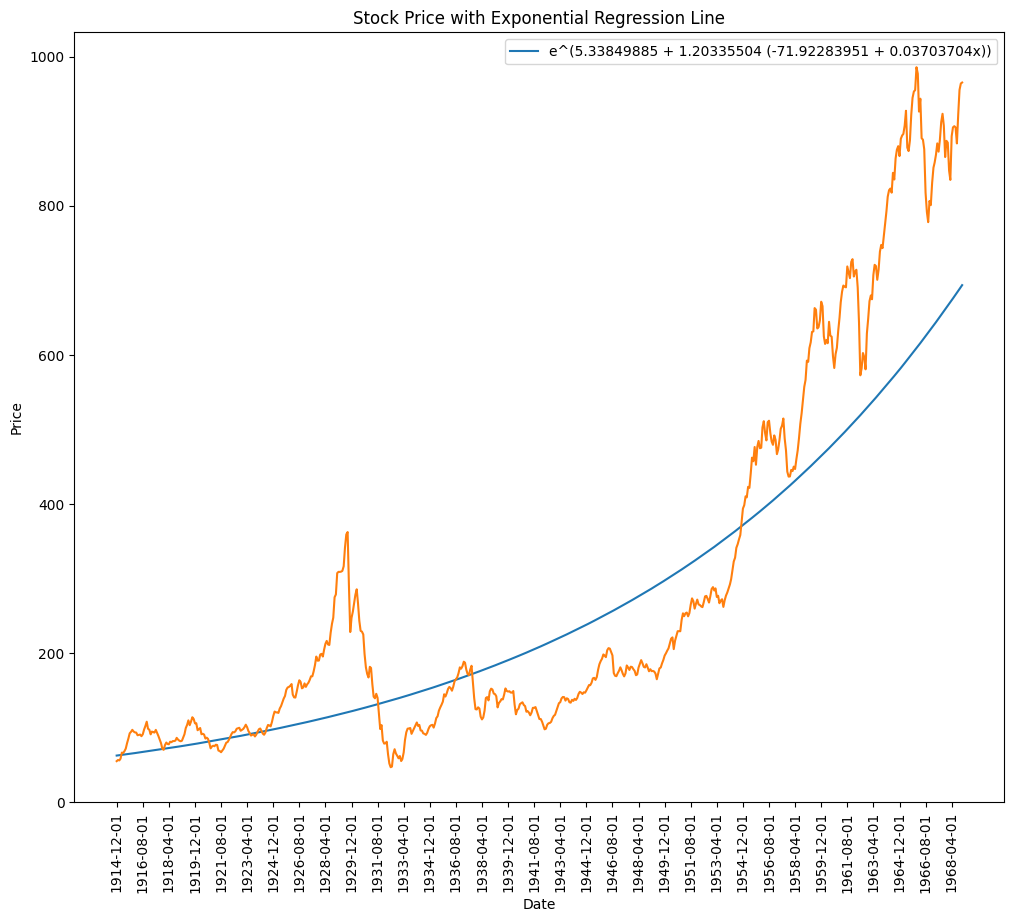

Annual Growth Rate
4.557681087444787 %


In [19]:


#===========================================================================
#EXPONENTIAL REGRESSSION

#============================================================================ 


import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_stocks = sns.load_dataset("dowjones")
x = (df_stocks.index+11)/12+1914
log_poly = np.polynomial.Polynomial.fit(x,np.log(df_stocks["Price"]), 1)
#The function try calling exp_reg(1970)
exp_reg = lambda t: np.exp(log_poly(t))
plt.figure(figsize=(12,10))
plt.plot(df_stocks["Date"], exp_reg(x), label="e^("+str(log_poly)+")")
sns.lineplot(df_stocks, x="Date", y="Price")
plt.title("Stock Price with Exponential Regression Line")
plt.xticks(df_stocks["Date"][::20], rotation=90)
plt.show()

print("Annual Growth Rate")
#Solving exp_reg(x) = exp_reg(0)*(1+p)^x gives annual rate
#As the above holds for all x, subbing in x=1 gives
#p = exp_reg(1)/exp_reg(0)-1
annual_growth_rate = exp_reg(1)/exp_reg(0)-1
print(annual_growth_rate*100, "%")